# Analysis of EG01-EG23 Cyclus scenario with Cymetric
Cymetric provides a python-based way to interact with your Cyclus SQLite 
output file. There are various "metrics" in Cymetric, which pull data from 
different tables in the output, and other metrics that combine tables 
to produce other metrics. 

The analysis problems explored in this workshop include:
* Visualizing the fuel cycle modeled in the scenario
* Plotting the number of reactors deployed against the 
  amount of electricity generated
* Plotting the amount of uranium sent to reactor types
* Calculating the activity of material sent to a waste facility. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cymetric as cym # Use an alias for cymetric
from cymetric import graphs

In [5]:
# Open the output file with Cymetric
database = cym.dbopen('eg01-eg23-simple.sqlite')
# Define the Evaluator Object 
eg23_evaluator = cym.Evaluator(database, write=False) #Don't write metrics to the database

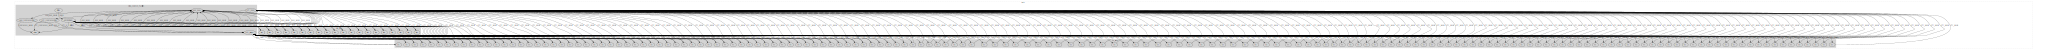

In [6]:
# Let's look at what the scenario looks like 
# Create a flow graph from the evaluator object
graphs.flow_graph(eg23_evaluator, label='comm')

## Compare the number of reactors and the amount of electricity produced
We have different metrics we will look at for this: 
* `BuildSeries`, to get the number of reactors that are commissioned
* `AnnualElectricityGeneratedByAgent`, to get the amount of electircity 
  generated by the reactors each year.

First, we will pull the BuildSeries metric, and sort out the data into the 
different prototypes. Second, we will pull the `AnnualElectricityGeneratedByAgent`
metric and organize the agents into each prototype. 
Then we will plot the build and electricity data together. 

In [20]:
# Get all metric data, then sort into LWR and SFR deployments
build_series = eg23_evaluator.eval('BuildSeries')
lwr_build = build_series.loc[build_series['Prototype'] == 'lwr']
sfr_build = build_series.loc[build_series['Prototype'] == 'fr']
reactor_build = pd.concat([lwr_build, sfr_build])

In [22]:
all_electricity

,SimId,AgentId,Year,Energy
0,eb142dd7-69c9-4628-a24f-9e61212f6b97,37,1,1000.000000
1,eb142dd7-69c9-4628-a24f-9e61212f6b97,37,2,916.666667
2,eb142dd7-69c9-4628-a24f-9e61212f6b97,37,3,1000.000000
3,eb142dd7-69c9-4628-a24f-9e61212f6b97,37,4,916.666667
4,eb142dd7-69c9-4628-a24f-9e61212f6b97,37,5,916.666667
...,...,...,...,...
14875,eb142dd7-69c9-4628-a24f-9e61212f6b97,222,241,300.000000
14876,eb142dd7-69c9-4628-a24f-9e61212f6b97,222,242,366.666667
14877,eb142dd7-69c9-4628-a24f-9e61212f6b97,222,243,366.666667
14878,eb142dd7-69c9-4628-a24f-9e61212f6b97,222,244,366.666667


In [21]:
# Get electiricty generated 
all_electricity = eg23_evaluator.eval('AnnualElectricityGeneratedByAgent')

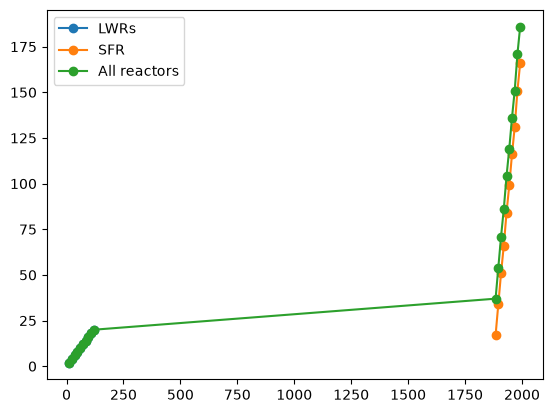

In [19]:
plt.plot(lwr_build['EnterTime'], lwr_build['Count'].cumsum(), 
         label='LWRs', marker = 'o')
plt.plot(sfr_build['EnterTime'], sfr_build['Count'].cumsum(),
         label='SFR', marker = 'o')
plt.plot(reactor_build['EnterTime'], reactor_build['Count'].cumsum(), 
         label='All reactors', marker='o')
plt.legend()